In [2]:
import pandas as pd
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    database="risk_data_mart",
    user="postgres",
    password="admin"
)

In [39]:
query = """
SELECT
* 
FROM loan_risk_features_v2
"""
df = pd.read_sql(query, conn)

df.head()

C:\Users\PC\AppData\Local\Temp\ipykernel_33160\559778144.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,loan_id,client_id,loan_amount,interest_rate,loan_date,due_date,status,days_overdue,total_paid,remaining_balance,percent_paid,risk_category
0,1,378,4214.49,0.142,2024-03-09,2025-03-09,paid,378,8823.5610,-4609.0703,2.093625,high_risk
1,2,763,4360.45,0.117,2025-08-23,2026-08-23,default,0,2810.0400,1550.4102,0.644438,no_risk
2,3,278,22654.03,0.054,2024-11-06,2025-11-06,paid,136,4107.2397,18546.7900,0.181303,high_risk
3,4,934,5658.55,0.134,2026-02-06,2027-02-06,active,0,11829.3300,-6170.7803,2.090523,no_risk
4,5,676,19932.79,0.106,2025-05-30,2026-05-30,default,0,11052.9000,8879.8890,0.554508,no_risk


In [4]:
df["remaining_balance"] = df["loan_amount"] - df["total_paid"]

df["percent_paid"] = df["total_paid"] / df["loan_amount"]

df.head()

,loan_id,name,loan_amount,total_paid,remaining_balance,percent_paid
0,251,Caroline Costa,30636.90,6193.7100,24443.1900,0.202165
1,163,Antony Lopes,28921.97,2872.0698,26049.9002,0.099304
2,892,Rebeca da Conceição,23312.60,0.0000,23312.6000,0.000000
3,604,Isaque Pimenta,34002.37,0.0000,34002.3700,0.000000
4,828,Srta. Ana Julia Almeida,18320.43,0.0000,18320.4300,0.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loan_id            600 non-null    int64  
 1   name               600 non-null    object 
 2   loan_amount        600 non-null    float64
 3   total_paid         600 non-null    float64
 4   remaining_balance  600 non-null    float64
 5   percent_paid       600 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 28.3+ KB


In [6]:
df.describe()

,loan_id,loan_amount,total_paid,remaining_balance,percent_paid
count,600.0000,600.000000,600.000000,600.000000,600.000000
mean,450.5000,24776.641500,3336.687554,21439.953946,0.286578
std,312.5103,13996.608726,4346.951204,14729.672147,0.889784
min,1.0000,1001.340000,0.000000,-13125.809000,0.000000
25%,150.7500,12330.727500,0.000000,9198.467500,0.000000
50%,450.5000,23722.830000,66.600000,21122.000000,0.004129
75%,750.2500,36861.895000,6429.265000,33602.628250,0.278390
max,900.0000,49842.750000,16150.720000,49611.540000,12.056758


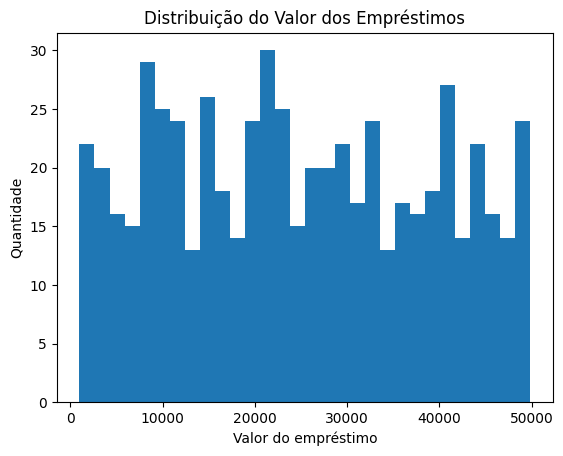

In [7]:
import matplotlib.pyplot as plt

plt.hist(df["loan_amount"], bins=30)
plt.title("Distribuição do Valor dos Empréstimos")
plt.xlabel("Valor do empréstimo")
plt.ylabel("Quantidade")
plt.show()

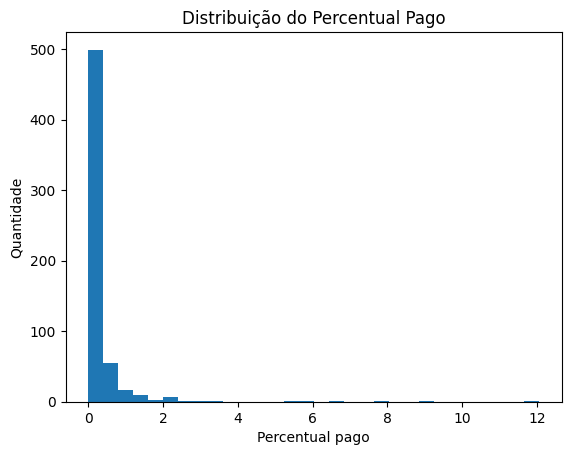

In [8]:
plt.hist(df["percent_paid"], bins=30)
plt.title("Distribuição do Percentual Pago")
plt.xlabel("Percentual pago")
plt.ylabel("Quantidade")
plt.show()

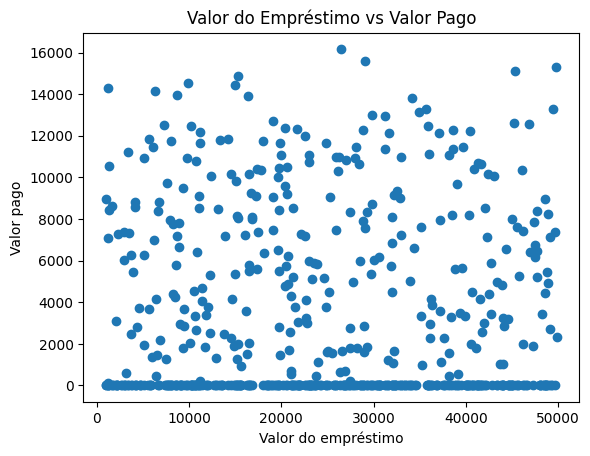

In [9]:
plt.scatter(df["loan_amount"], df["total_paid"])
plt.title("Valor do Empréstimo vs Valor Pago")
plt.xlabel("Valor do empréstimo")
plt.ylabel("Valor pago")
plt.show()

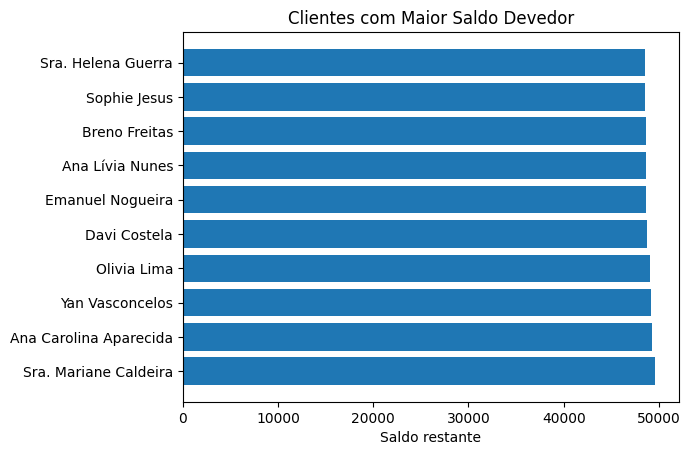

In [10]:
top_debt = df.sort_values("remaining_balance", ascending=False).head(10)

plt.barh(top_debt["name"], top_debt["remaining_balance"])
plt.title("Clientes com Maior Saldo Devedor")
plt.xlabel("Saldo restante")
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_33160\632944832.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("loan_bucket")["percent_paid"].mean().plot(kind="bar")


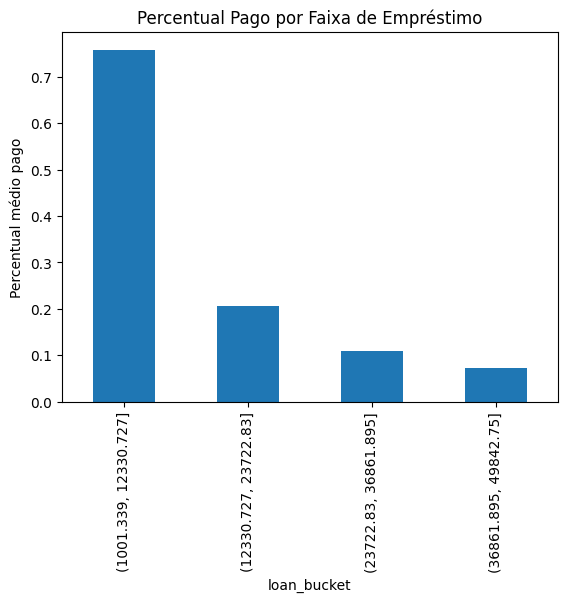

In [11]:
df["loan_bucket"] = pd.qcut(df["loan_amount"], 4)

df.groupby("loan_bucket")["percent_paid"].mean().plot(kind="bar")

plt.title("Percentual Pago por Faixa de Empréstimo")
plt.ylabel("Percentual médio pago")
plt.show()

In [12]:
df["risk_flag"] = df["percent_paid"] < 0.3

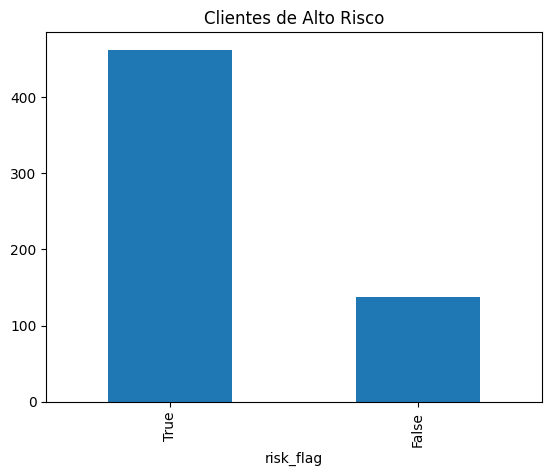

In [13]:
df["risk_flag"].value_counts().plot(kind="bar")

plt.title("Clientes de Alto Risco")
plt.show()

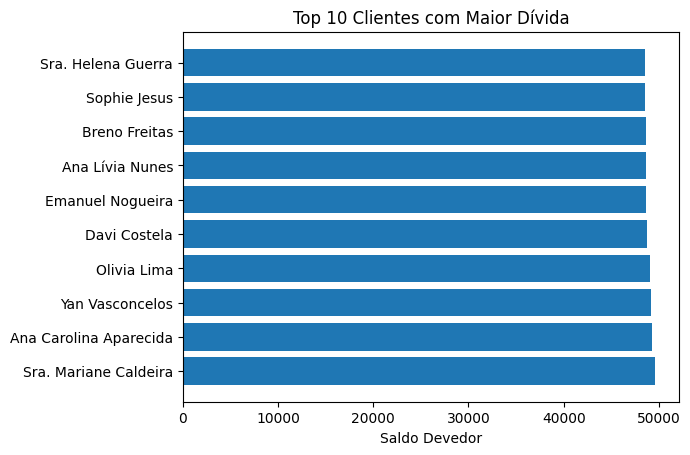

In [14]:
top_debt = df.sort_values("remaining_balance", ascending=False)

top_10 = top_debt.head(10)

import matplotlib.pyplot as plt

plt.barh(top_10["name"], top_10["remaining_balance"])
plt.title("Top 10 Clientes com Maior Dívida")
plt.xlabel("Saldo Devedor")
plt.show()

### Observa-se que uma pequena parcela dos clientes concentra a maior parte da exposição de crédito, indicando possível risco concentrado no portfólio.

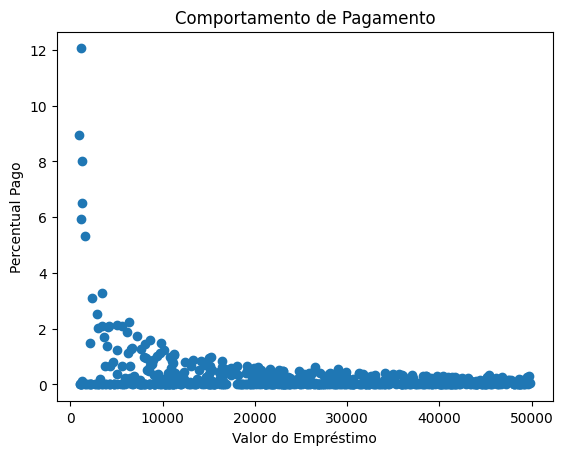

In [15]:
plt.scatter(df["loan_amount"], df["percent_paid"])

plt.title("Comportamento de Pagamento")
plt.xlabel("Valor do Empréstimo")
plt.ylabel("Percentual Pago")

plt.show()

### O gráfico de dispersão mostra que clientes com empréstimos maiores tendem a pagar uma porcentagem menor, sugerindo que empréstimos maiores podem estar associados a um risco de inadimplência mais elevado.

In [16]:
def risk_level(p):
    if p < 0.3:
        return "High Risk"
    elif p < 0.7:
        return "Medium Risk"
    else:
        return "Low Risk"

df["risk_level"] = df["percent_paid"].apply(risk_level)

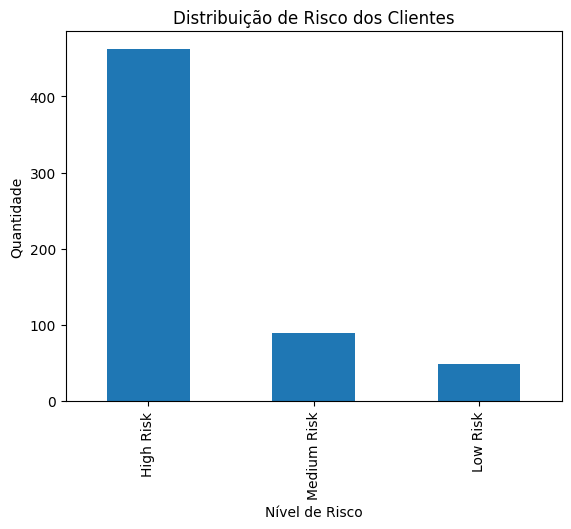

In [17]:
df["risk_level"].value_counts().plot(kind="bar")

plt.title("Distribuição de Risco dos Clientes")
plt.xlabel("Nível de Risco")
plt.ylabel("Quantidade")

plt.show()

### Uma parcela relevante dos clientes apresenta baixo percentual pago, indicando um grupo de clientes com potencial risco de inadimplência.

In [18]:
df.groupby("name")["remaining_balance"].mean().sort_values(ascending=False).head(10)

name
Sra. Mariane Caldeira     49611.54
Ana Carolina Aparecida    49313.14
Yan Vasconcelos           49206.34
Davi Costela              48789.35
Emanuel Nogueira          48670.83
Ana Lívia Nunes           48669.58
Breno Freitas             48667.26
Sra. Helena Guerra        48493.02
Isaque Duarte             48484.36
Ana Beatriz Moura         48068.31
Name: remaining_balance, dtype: float64

In [19]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt

conn = psycopg2.connect(
    host="localhost",
    database="risk_data_mart",
    user="postgres",
    password="admin"
)

query = "SELECT * FROM loan_risk_features_v2;"
df = pd.read_sql(query, conn)

df.head()

C:\Users\PC\AppData\Local\Temp\ipykernel_33160\3965862071.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,loan_id,client_id,loan_amount,interest_rate,loan_date,due_date,status,days_overdue,total_paid,remaining_balance,percent_paid,risk_category
0,1,378,4214.49,0.142,2024-03-09,2025-03-09,paid,378,8823.5610,-4609.0703,2.093625,high_risk
1,2,763,4360.45,0.117,2025-08-23,2026-08-23,default,0,2810.0400,1550.4102,0.644438,no_risk
2,3,278,22654.03,0.054,2024-11-06,2025-11-06,paid,136,4107.2397,18546.7900,0.181303,high_risk
3,4,934,5658.55,0.134,2026-02-06,2027-02-06,active,0,11829.3300,-6170.7803,2.090523,no_risk
4,5,676,19932.79,0.106,2025-05-30,2026-05-30,default,0,11052.9000,8879.8890,0.554508,no_risk


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loan_id            600 non-null    int64  
 1   client_id          600 non-null    int64  
 2   loan_amount        600 non-null    float64
 3   interest_rate      600 non-null    float64
 4   loan_date          600 non-null    object 
 5   due_date           600 non-null    object 
 6   status             600 non-null    object 
 7   days_overdue       600 non-null    int64  
 8   total_paid         600 non-null    float64
 9   remaining_balance  600 non-null    float64
 10  percent_paid       600 non-null    float64
 11  risk_category      600 non-null    object 
dtypes: float64(5), int64(3), object(4)
memory usage: 56.4+ KB


In [21]:
df.describe

<bound method NDFrame.describe of      loan_id  client_id  loan_amount  interest_rate   loan_date    due_date  \
0          1        378      4214.49          0.142  2024-03-09  2025-03-09   
1          2        763      4360.45          0.117  2025-08-23  2026-08-23   
2          3        278     22654.03          0.054  2024-11-06  2025-11-06   
3          4        934      5658.55          0.134  2026-02-06  2027-02-06   
4          5        676     19932.79          0.106  2025-05-30  2026-05-30   
..       ...        ...          ...            ...         ...         ...   
595      896        353     45658.53          0.024  2025-09-14  2026-09-14   
596      897        265     15181.50          0.074  2024-08-02  2025-08-02   
597      898        841      9091.89          0.150  2024-10-27  2025-10-27   
598      899        768     20615.62          0.109  2025-01-09  2026-01-09   
599      900        467     21227.10          0.116  2025-07-01  2026-07-01   

      status  day

## Quantidade de empréstimos por catergoria de risco

Esse gráfico mostra a distribuição da carteira entre risco baixo, médio e alto. Observa-se que a maioria dos clientes está na categoria de sem risco, seguida pela categoria de risco alto, medio risco esta 5 vezes menor que a categoria de risco alto,indicando uma concentração significativa de clientes com risco elevado, baixo risco representa uma parcela menor da carteira, o que pode indicar uma estratégia de concessão de crédito mais conservadora ou um perfil de clientes mais arriscado.

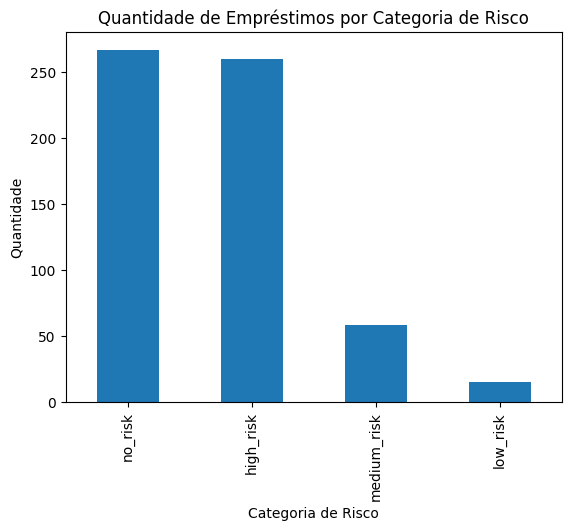

In [22]:
df["risk_category"].value_counts().plot(kind="bar")
plt.title("Quantidade de Empréstimos por Categoria de Risco")
plt.xlabel("Categoria de Risco")
plt.ylabel("Quantidade")
plt.show()

## Saldo restante médio por categoria de risco

baixo risco tem o maior saldo restante médio, seguido por médio risco e sem risco, alto risco tem o menor saldo restante médio, indicando que clientes com maior risco tendem a ter saldos menores, o que pode refletir uma estratégia de concessão de crédito mais restritiva para clientes considerados mais arriscados.


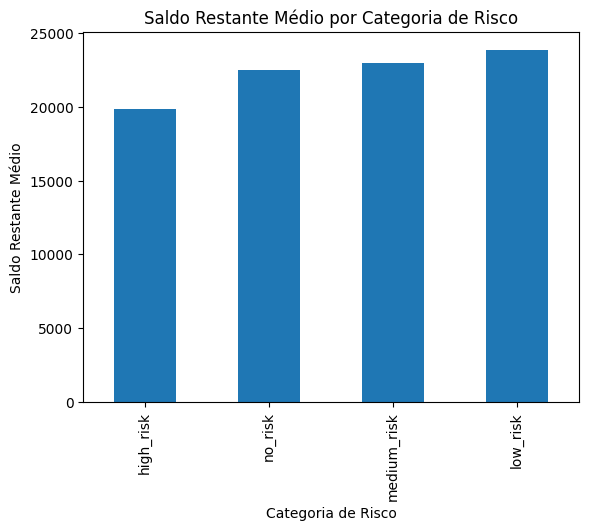

In [23]:
df.groupby("risk_category")["remaining_balance"].mean().sort_values().plot(kind="bar")
plt.title("Saldo Restante Médio por Categoria de Risco")
plt.xlabel("Categoria de Risco")
plt.ylabel("Saldo Restante Médio")
plt.show()

## Percentual pago médio por categoria de risco

alto risco tem o maior percentual pago médio, seguido por sem risco e baixo risco, risco médio tem o menor percentual pago médio, indicando que clientes com maior risco tendem a pagar uma porcentagem maior de seus empréstimos, o que pode refletir uma estratégia de cobrança mais agressiva ou um comportamento de pagamento mais diligente por parte desses clientes.

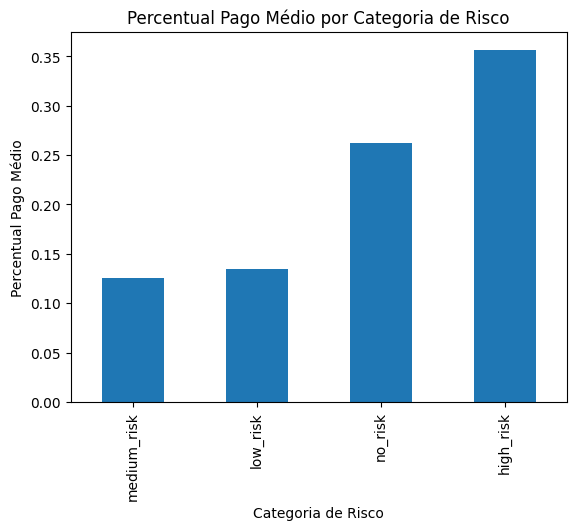

In [24]:
df.groupby("risk_category")["percent_paid"].mean().sort_values().plot(kind="bar")
plt.title("Percentual Pago Médio por Categoria de Risco")
plt.xlabel("Categoria de Risco")
plt.ylabel("Percentual Pago Médio")
plt.show()

## Dispersão entre valor do empréstimo e valor pago

Conseguimos ver contratos de alto valor liberado e baixo.

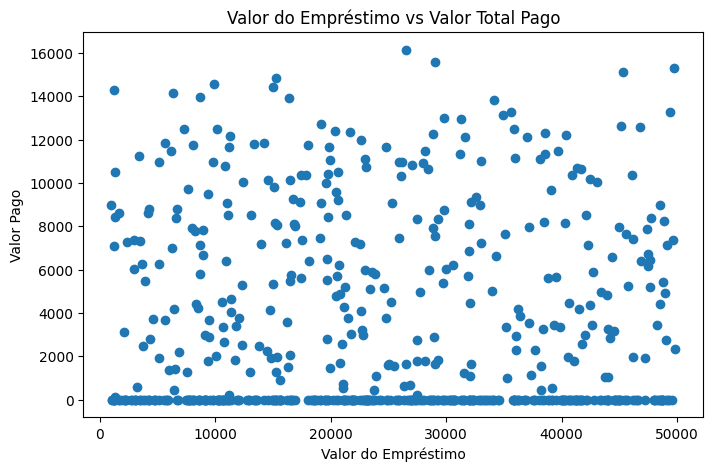

In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(df["loan_amount"], df["total_paid"])
plt.title("Valor do Empréstimo vs Valor Total Pago")
plt.xlabel("Valor do Empréstimo")
plt.ylabel("Valor Pago")
plt.show()

## top 10 maiores saldos devedores

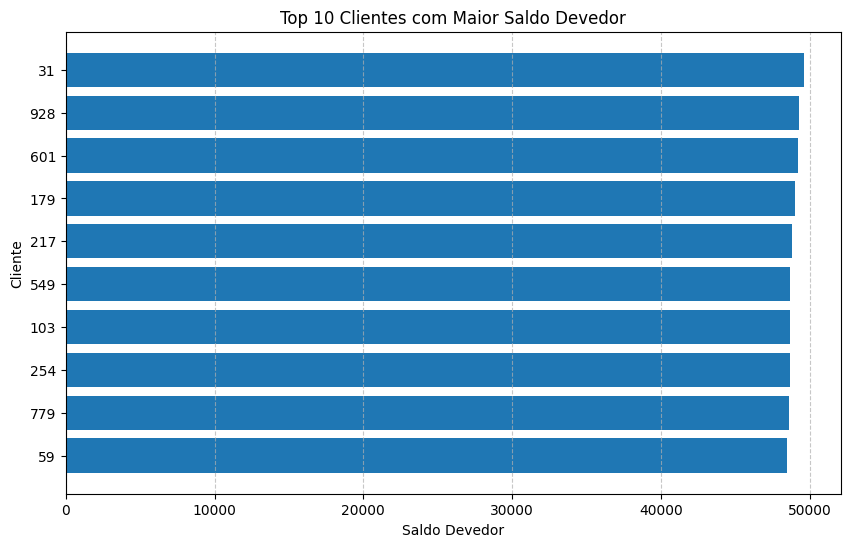

In [45]:
top_10 = df.sort_values("remaining_balance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_10["client_id"].astype(str), top_10["remaining_balance"])
plt.title("Top 10 Clientes com Maior Saldo Devedor")
plt.xlabel("Saldo Devedor")
plt.ylabel("Cliente")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

## Correlações entre as variáveis numéricas

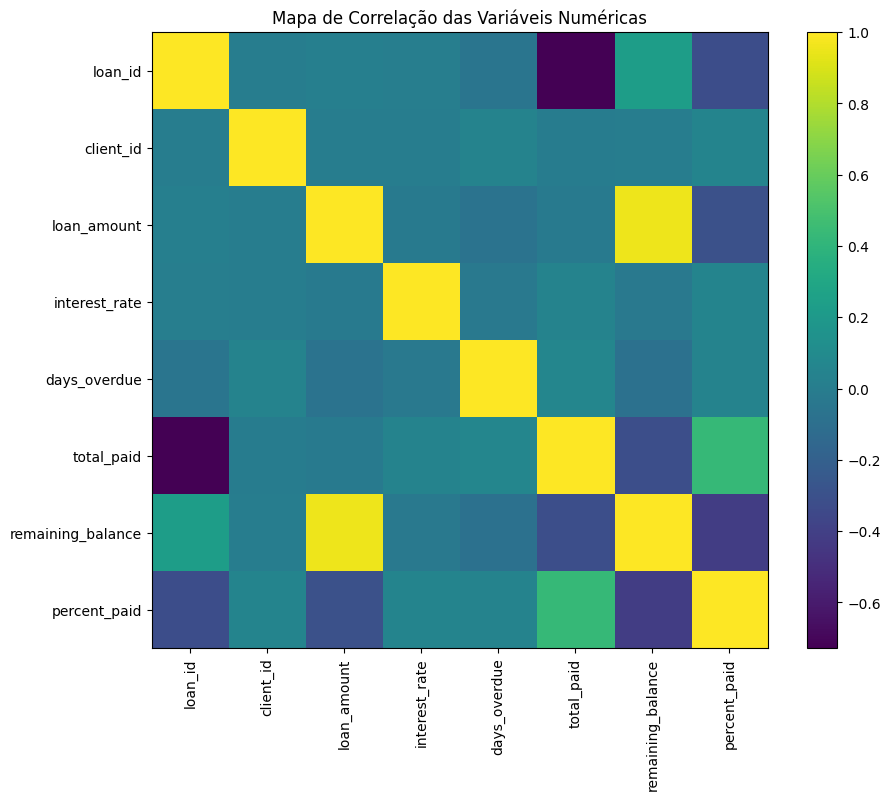

In [44]:
corr = df.select_dtypes(include=["number"    
]).corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Mapa de Correlação das Variáveis Numéricas")
plt.show()

## Tabela resumo de risco

In [36]:
risk_summary = df.groupby("risk_category").agg(
    total_loans=("loan_id", "count"),
    avg_loan_amount=("loan_amount", "mean"),
    avg_total_paid=("total_paid", "mean"),
    avg_remaining_balance=("remaining_balance", "mean"),
    avg_percent_paid=("percent_paid", "mean"),

).reset_index()

risk_summary

,risk_category,total_loans,avg_loan_amount,avg_total_paid,avg_remaining_balance,avg_percent_paid
0,high_risk,260,23536.653538,3657.714894,19878.938645,0.356704
1,low_risk,15,27272.083333,3407.379987,23864.703267,0.134614
2,medium_risk,58,24993.972931,2052.237115,22941.735779,0.125295
3,no_risk,267,25796.716479,3299.124372,22497.592103,0.261863
